In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1053.000000  1053.000000  1053.000000    1053.000000  1053.000000   
mean      0.742409     0.439729     0.569271       0.677491     0.639391   
std       0.088425     0.265266     0.225012       0.156629     0.130632   
min       0.562450     0.105000     0.282779       0.413926     0.398362   
25%       0.666932     0.205000     0.368580       0.543520     0.537975   
50%       0.722395     0.330000     0.447734       0.659574     0.585629   
75%       0.822678     0.705000     0.833233       0.823985     0.742740   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1053.000000  1053.000000  1053.000000  1053.000000  1053.000000  ...   
mean      0.579518     0.708807     0.577296     0.577655     0.648942  ...   
std       0.223563     0.130110     0.206169     0.221963     0.150149  ...   
min       0.282471     0.474490     0.291237     0.300840     0.407917  ...   
25%       0.389656     0.610544     0.409181     0.381996     0.537866  ...   
50%       0.464311     0.675170     0.463211     0.491138     0.577022  ...   
75%       0.819565     0.795918     0.799473     0.831157     0.770654  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1053.000000  1053.000000  1053.000000  1053.000000  1053.000000   
mean      0.510921     0.747585     0.796144     0.636339     0.831713   
std       0.264535     0.144739     0.124806     0.216244     0.088030   
min       0.173387     0.526202     0.579721     0.314732     0.705682   
25%       0.248245     0.595003     0.668563     0.423274     0.738409   
50%       0.493574     0.796658     0.835030     0.664793     0.843182   
75%       0.759020     0.865362     0.895134     0.827631     0.905455   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1053.000000  1053.000000  1053.000000  1053.000000  1053.000000  
mean      0.795569     0.748079     0.790263     0.732994     0.818326  
std       0.114778     0.124496     0.127852     0.170755     0.082584  
min       0.576577     0.562215     0.589215     0.476923     0.696167  
25%       0.667568     0.629915     0.655181     0.552755     0.730681  
50%       0.828829     0.775392     0.839353     0.782939     0.825685  
75%       0.888889     0.834907     0.894076     0.890644     0.879428  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x1f7895a5590>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

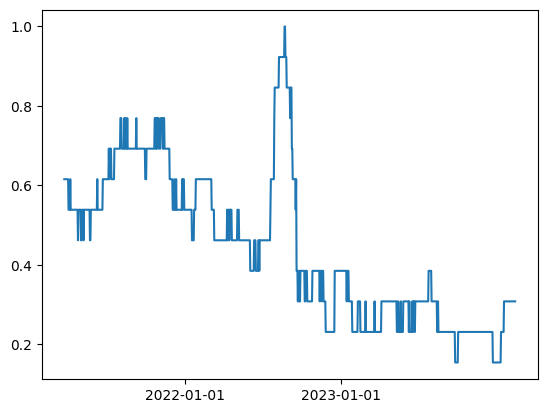

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels)
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

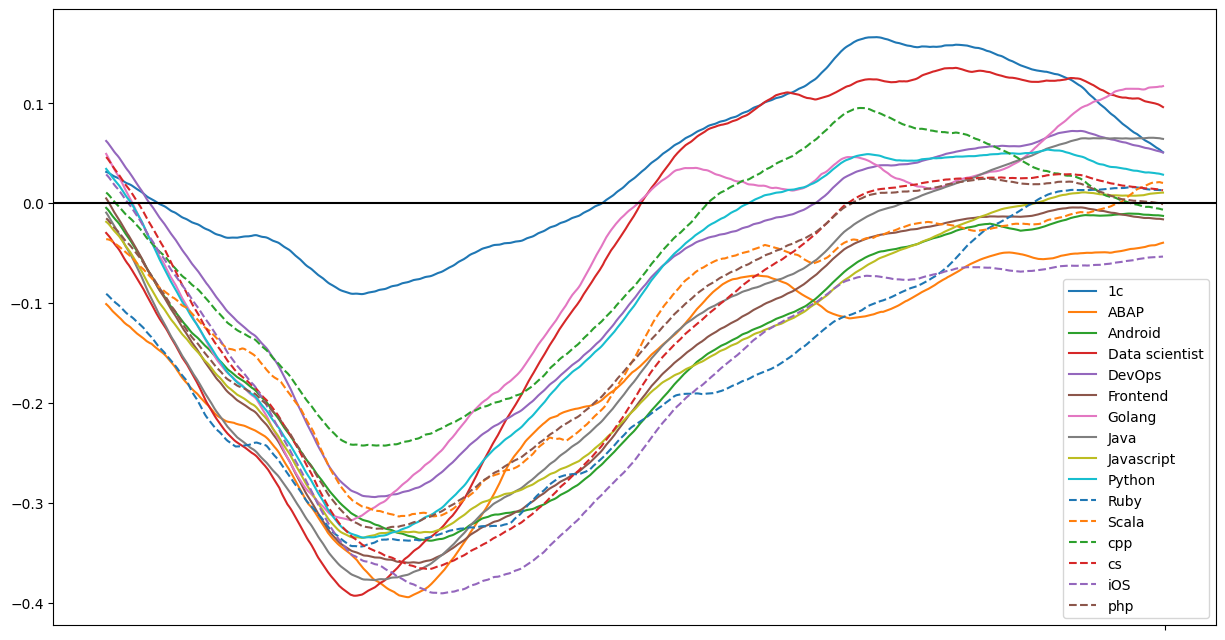

In [8]:
graphs('val', 200)

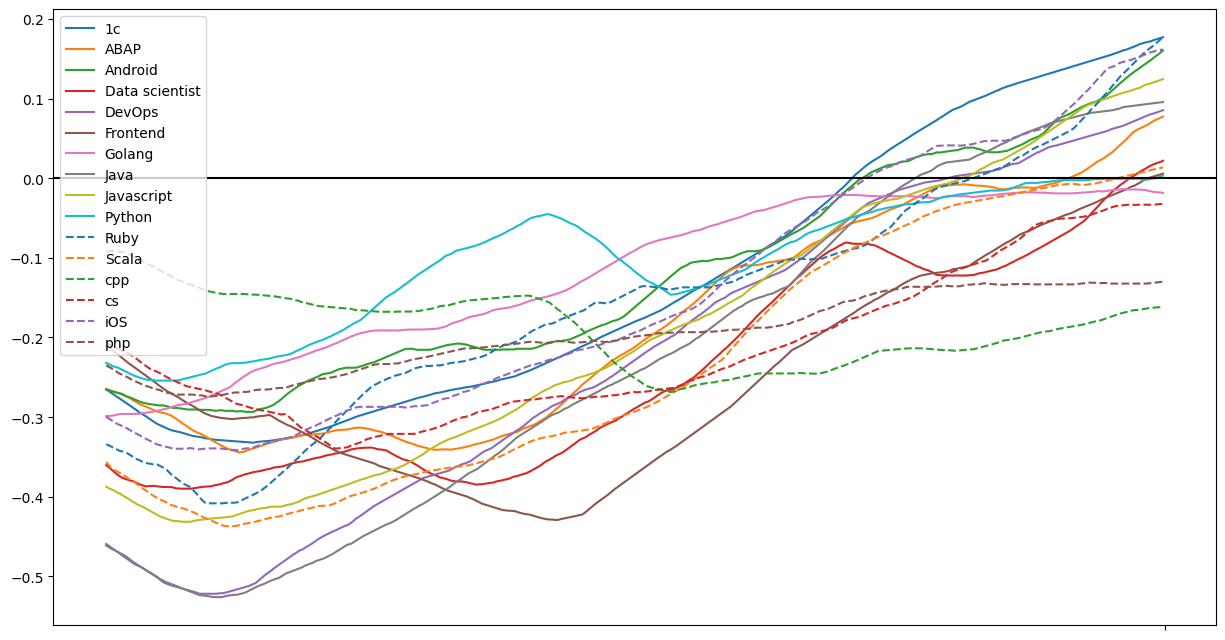

In [9]:
graphs('val_noexp', 300)

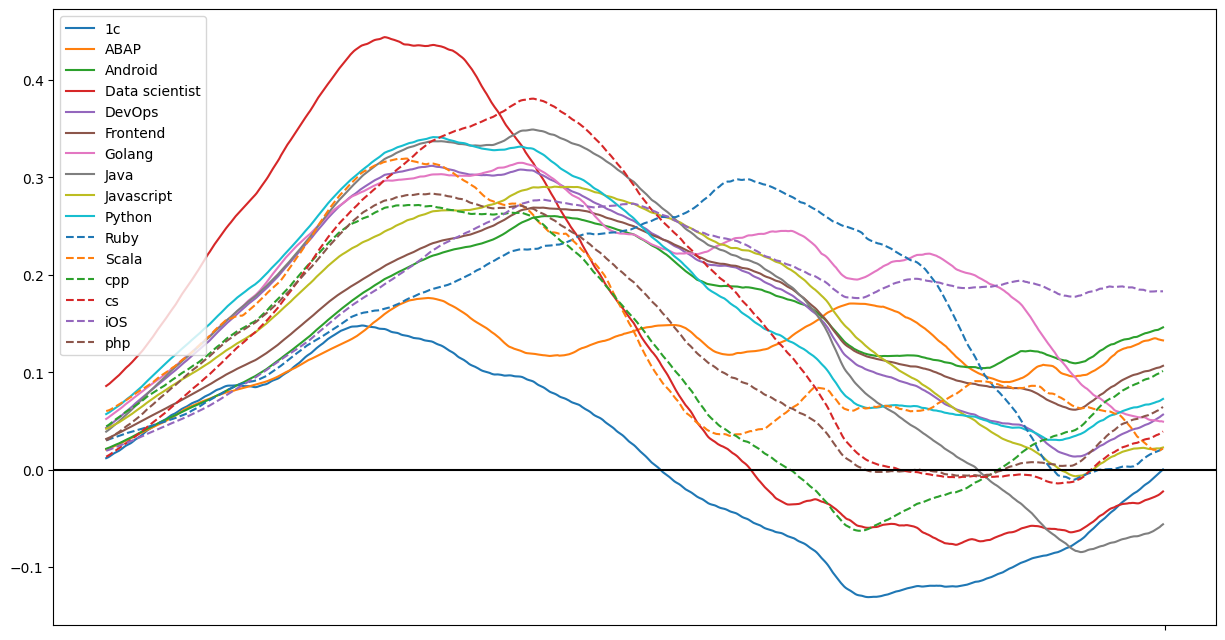

In [10]:
graphs('res_vac', 200)

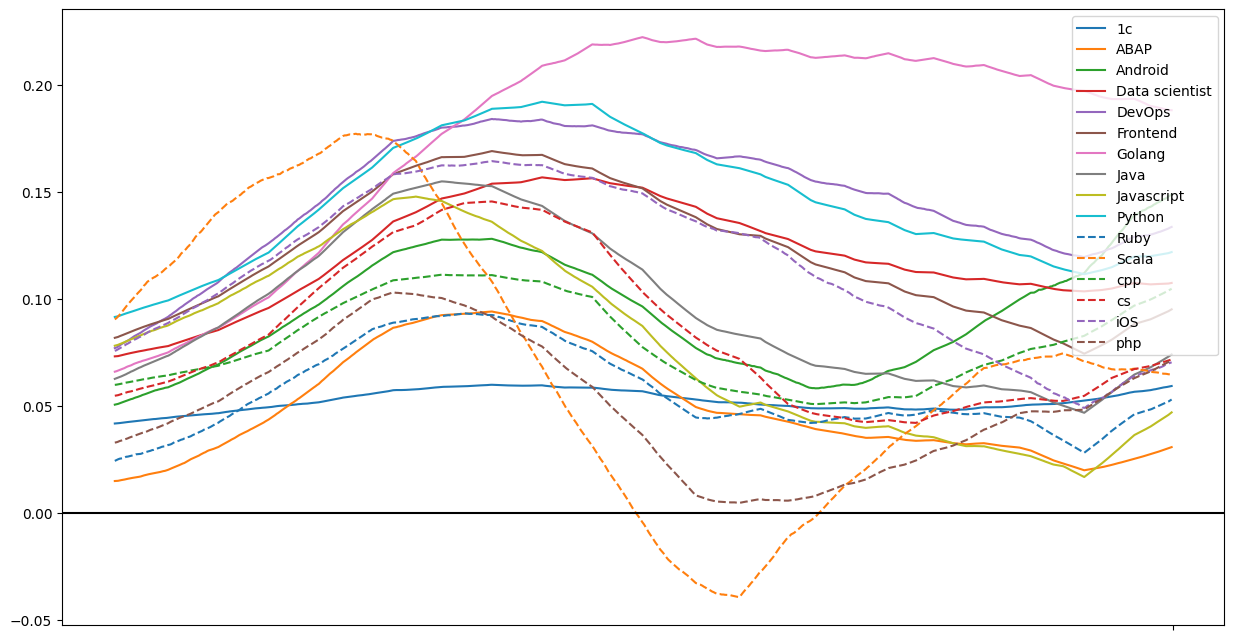

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1053 entries, 2021-03-26 to 2024-02-13
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1053 non-null   float64
 1   (val, ABAP)                  1053 non-null   float64
 2   (val, Android)               1053 non-null   float64
 3   (val, Data scientist)        1053 non-null   float64
 4   (val, DevOps)                1053 non-null   float64
 5   (val, Frontend)              1053 non-null   float64
 6   (val, Golang)                1053 non-null   float64
 7   (val, Java)                  1053 non-null   float64
 8   (val, Javascript)            1053 non-null   float64
 9   (val, Python)                1053 non-null   float64
 10  (val, Ruby)                  1053 non-null   float64
 11  (val, Scala)                 1053 non-null   float64
 12  (val, cpp)                   1053 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

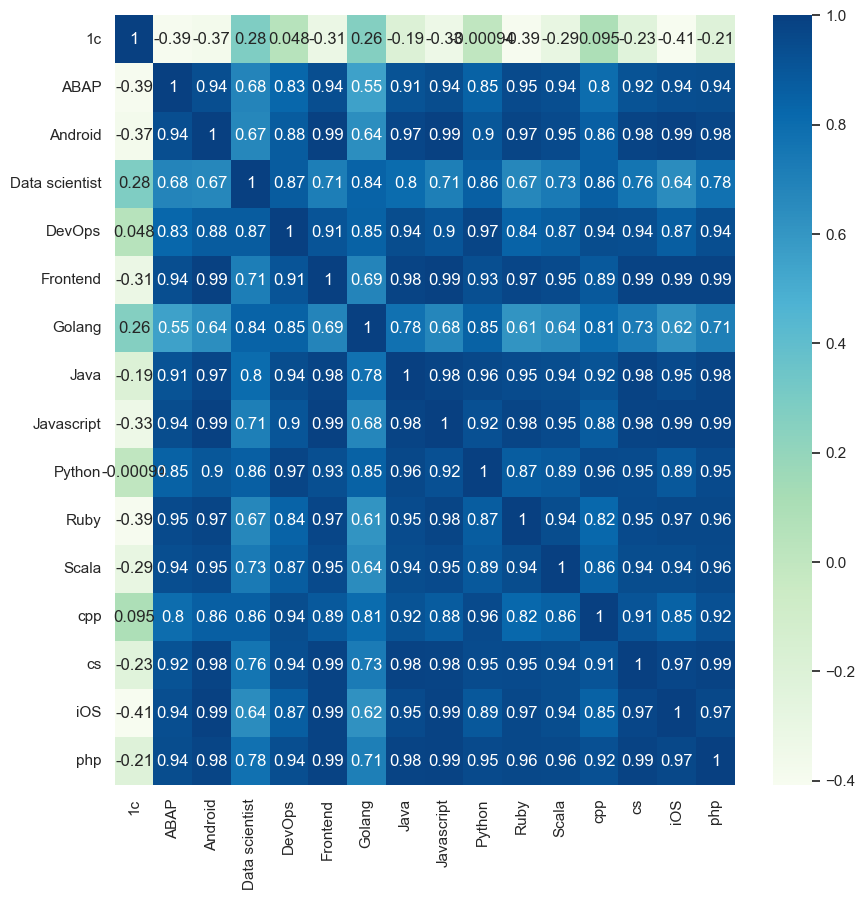

In [14]:
corr('val')

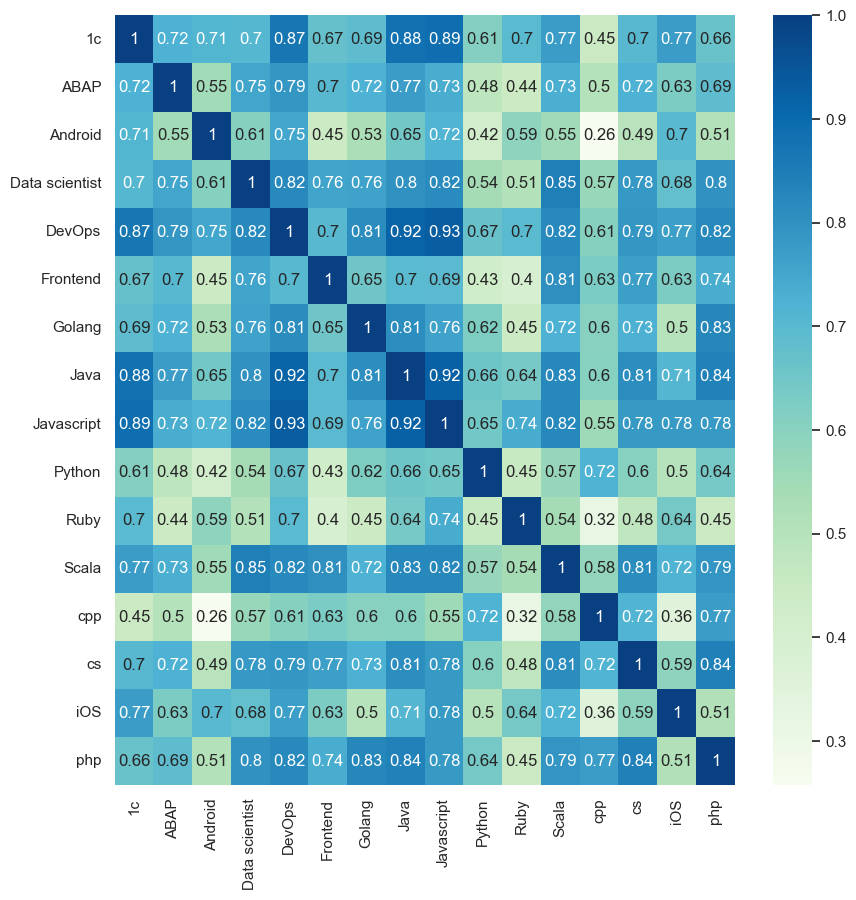

In [15]:
corr('val_noexp')

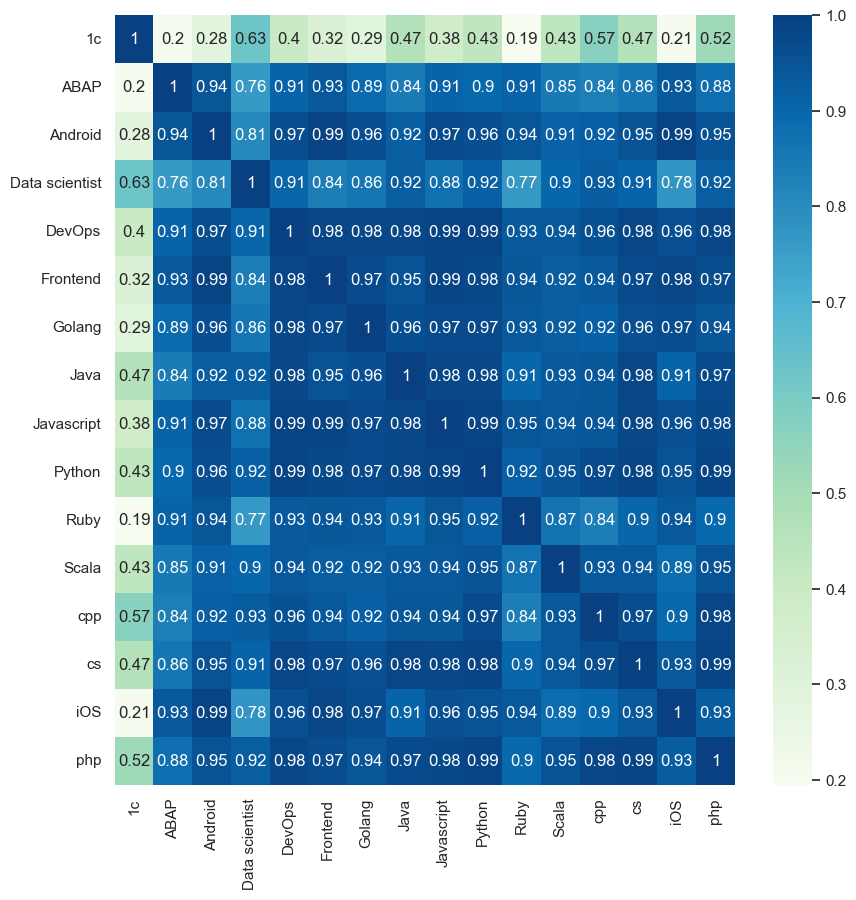

In [16]:
corr('res_vac')

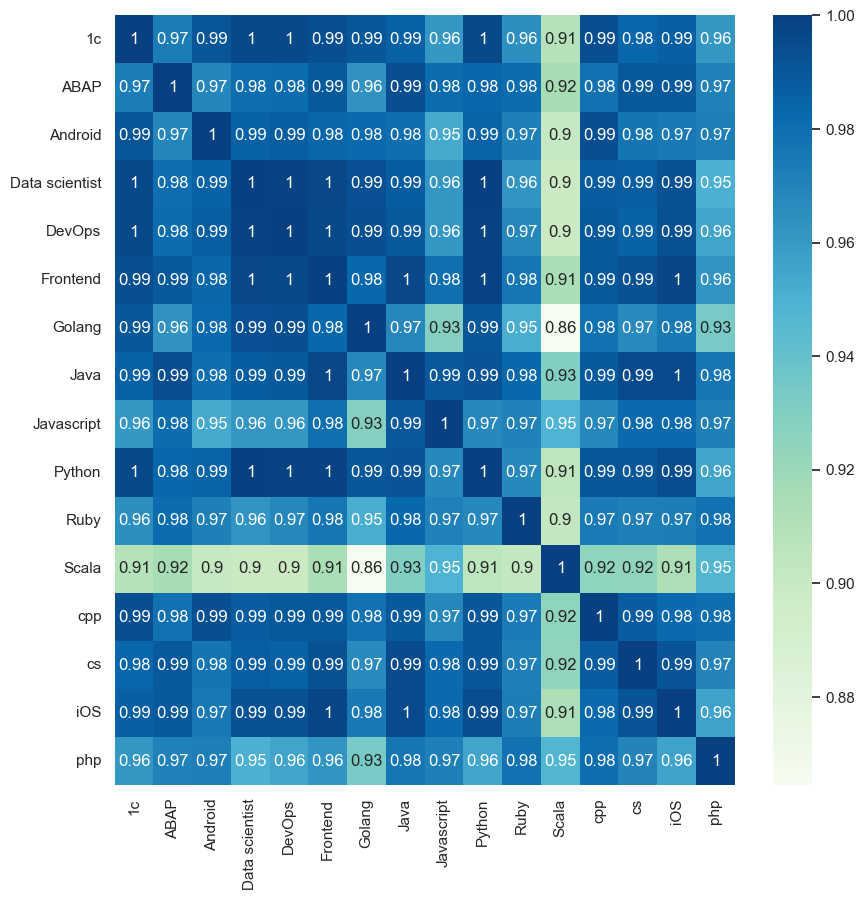

In [17]:
corr('res')

In [18]:
langs

val                                                      \
                  1c   ABAP   Android Data scientist    DevOps  Frontend   
date_added                                                                 
2021-03-26  0.655420  0.825  0.749849       0.854932  0.746091  0.767377   
2021-03-27  0.649917  0.825  0.740785       0.847195  0.736039  0.762696   
2021-03-28  0.638839  0.775  0.726888       0.816248  0.718541  0.752165   
2021-03-29  0.628267  0.760  0.707553       0.800774  0.703276  0.731102   
2021-03-30  0.651003  0.825  0.729909       0.833656  0.721891  0.760122   
...              ...    ...       ...            ...       ...       ...   
2024-02-09  0.980885  0.180  0.368580       0.835590  0.657856  0.414697   
2024-02-10  0.969155  0.180  0.359517       0.810445  0.657856  0.413761   
2024-02-11  0.945913  0.180  0.351662       0.785300  0.642591  0.403230   
2024-02-12  0.923177  0.180  0.345619       0.775629  0.625838  0.393634   
2024-02-13  0.950329  0.185  0.349849       0.787234  0.650782  0.397847   

                                                     ...       res            \
              Golang      Java Javascript    Python  ...    Golang      Java   
date_added                                           ...                       
2021-03-26  0.615646  0.766528   0.841418  0.723322  ...  0.189294  0.533271   
2021-03-27  0.603741  0.757742   0.792910  0.711704  ...  0.185634  0.527160   
2021-03-28  0.595238  0.748078   0.778451  0.706110  ...  0.183019  0.529567   
2021-03-29  0.583333  0.730727   0.750466  0.698795  ...  0.188799  0.526202   
2021-03-30  0.625850  0.750494   0.785914  0.715577  ...  0.182304  0.531277   
...              ...       ...        ...       ...  ...       ...       ...   
2024-02-09  0.938776  0.529541   0.417444  0.643287  ...  0.987478  0.995328   
2024-02-10  0.926871  0.522073   0.419310  0.645439  ...  0.989955  0.994035   
2024-02-11  0.908163  0.508895   0.407183  0.629088  ...  0.999367  1.000000   
2024-02-12  0.901361  0.497694   0.397854  0.616179  ...  0.991881  0.996212   
2024-02-13  0.926871  0.513508   0.413246  0.623494  ...  0.989955  0.996528   

                                                                         \
           Javascript    Python      Ruby     Scala       cpp        cs   
date_added                                                                
2021-03-26   0.581748  0.315716  0.732727  0.620721  0.567452  0.594583   
2021-03-27   0.587368  0.314732  0.732727  0.612913  0.566509  0.592105   
2021-03-28   0.589472  0.316314  0.741818  0.605105  0.562320  0.594753   
2021-03-29   0.580635  0.317050  0.727273  0.609009  0.564451  0.594544   
2021-03-30   0.582185  0.316445  0.725682  0.628529  0.565655  0.593058   
...               ...       ...       ...       ...       ...       ...   
2024-02-09   0.996414  0.997516  1.000000  0.994595  0.994821  0.998624   
2024-02-10   0.993965  0.997146  0.998182  1.000000  0.999932  0.999967   
2024-02-11   0.998733  0.997175  0.996970  0.988889  0.999691  0.998816   
2024-02-12   0.995501  0.997946  0.998409  0.992793  0.995219  0.995293   
2024-02-13   1.000000  0.999051  0.998409  0.995495  0.997842  0.995375   

                                
                 iOS       php  
date_added                      
2021-03-26  0.476923  0.705287  
2021-03-27  0.487110  0.701099  
2021-03-28  0.480249  0.703775  
2021-03-29  0.482874  0.699756  
2021-03-30  0.477677  0.700244  
...              ...       ...  
2024-02-09  0.999155  0.994079  
2024-02-10  0.995972  0.992305  
2024-02-11  0.997193  0.996627  
2024-02-12  1.000000  0.999453  
2024-02-13  0.996323  0.997906  

[1053 rows x 64 columns]